In [1]:
!pip -q install nilearn nibabel pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 31.9 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nilearn import datasets, plotting, image

In [3]:
localizer = datasets.fetch_localizer_first_level()
print(localizer.keys())

[fetch_localizer_first_level] Added README.md to /root/nilearn_data

[fetch_localizer_first_level] Dataset created in /root/nilearn_data/localizer_first_level

[fetch_localizer_first_level] Downloading data from https://osf.io/2bqxn/download ...

[fetch_localizer_first_level] Downloaded 180224 of 34532740 bytes (0.5%%,  3.2min remaining)

[fetch_localizer_first_level] Downloaded 1425408 of 34532740 bytes (4.1%%,   46.5s remaining)

...

[fetch_localizer_first_level] Downloaded 23855104 of 34532740 bytes (69.1%%,    1.8s remaining)

[fetch_localizer_first_level]  ...done. (8 seconds, 0 min)

[fetch_localizer_first_level] Extracting data from 
/root/nilearn_data/localizer_first_level/cac0ef0f4307834e60fedd2a0448862a/download...

[fetch_localizer_first_level] .. done.

dict_keys(['epi_img', 'events', 'description', 't_r', 'slice_time_ref'])


In [5]:
print("Available keys:", localizer.keys())
print("EPI file:", localizer.epi_img)
print("Events file:", localizer.events)

Available keys: dict_keys(['epi_img', 'events', 'description', 't_r', 'slice_time_ref'])
EPI file: /root/nilearn_data/localizer_first_level/localizer_first_level/sub-12069_task-localizer_space-MNI305.nii.gz
Events file: /root/nilearn_data/localizer_first_level/localizer_first_level/sub-12069_task-localizer_events.tsv


In [6]:
events = pd.read_csv(localizer.events, sep="\t")
events.head()

,trial_type,onset,duration
0,visual_computation,0.0,1.0
1,visual_computation,2.4,1.0
2,horizontal_checkerboard,8.7,1.0
3,audio_right_hand_button_press,11.4,1.0
4,sentence_listening,15.0,1.0


In [7]:
img = image.load_img(localizer.epi_img)
print("Image shape:", img.shape)


Image shape: (53, 63, 46, 128)


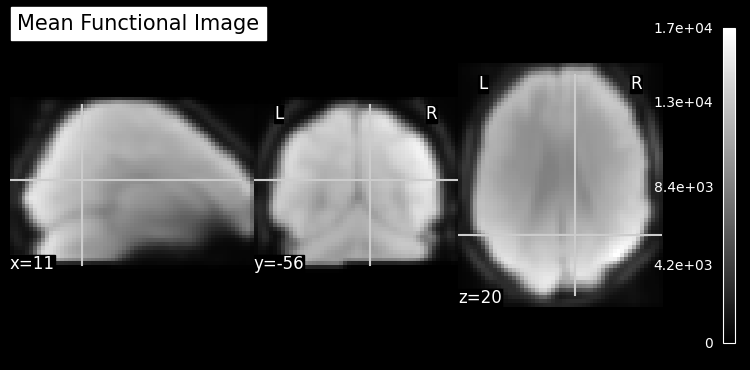

In [8]:
mean_img = image.mean_img(img)
plotting.plot_epi(mean_img, title="Mean Functional Image")
plotting.show()

In [9]:
print(f"Number of events: {len(events)}")
print("Conditions:", events['trial_type'].unique())
print("Volumes:", img.shape[-1])

Number of events: 80
Conditions: ['visual_computation' 'horizontal_checkerboard'
 'audio_right_hand_button_press' 'sentence_listening'
 'visual_right_hand_button_press' 'audio_left_hand_button_press'
 'visual_left_hand_button_press' 'vertical_checkerboard'
 'audio_computation' 'sentence_reading']
Volumes: 128
